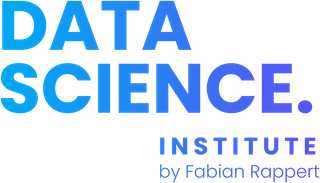

# Inhaltsverzeichnis 

- **Requests**
    - **Webseite**
    - **Response Objekt**
    - **Parameter senden**

# Requests 

Die [requests](https://pypi.org/project/requests/) Bibliothek ist eine Python-Bibliothek, die es ermöglicht, HTTP-Anfragen aus Python-Code heraus zu senden und die Antwort des Servers zu verarbeiten.

Die `requests` Bibliothek stellt eine einfache, aber mächtige Schnittstelle für das Senden von HTTP-Anfragen bereit und unterstützt unter anderem:

- Anpassung von HTTP-Header
- Bearbeitung von URL-Parametern
- Verarbeitung von Cookies
- Handling von HTTP-Authentifizierung
- Einfache Datei-Uploads
- Unterstützung für Proxies

Das bedeutet, dass Entwickler mit der `requests` Bibliothek in der Lage sind, HTTP-Server in Python-Anwendungen einfach und effektiv zu nutzen, um z.B. Daten von APIs abzurufen, Daten zu senden, auf Webseiten zu zugreifen, Dateien herunterzuladen oder auf Cloud-Dienste zuzugreifen.

In [1]:
import requests

## Webseite 

Wir können mit Python eine Anfrage an eine Webseite schicken, genauso wie es jeder Browser macht. Die Antwort des Servers wird meistens ein Abschnitt von `HTML`-Code sein, welcher den Aufbau der Website beschreibt. 

Betrachte die Website https://de.wikipedia.org/wiki/Python_(Programmiersprache). Wenn du diese im Browser öffnest, wird die HTML-Datei dargestellt, die vom Server zurückgeschickt wird. Wir können diese Anfrage nun stattdessen über `Python` starten.

Dies funktioniert über die Funktion

`get(URL)`

welcher die Antwort bei einer Anfrage an der `URL` zurückliefert. Die Antwort ist ein sogenanntes `Response`-Objekt. Über dieses Objekt können wir uns die vom Server geschickten Informationen anzeigen lassen.

In den Richtlinien (https://wikitech.wikimedia.org/wiki/Robot_policy) von Wikipedia müssen wir bei einer API-Anfrage zusätzlich einen User-Agent hinzufügen. Dazu benötigen wir deine Mail-Adresse bzw. du kannst dir eine temporäre Mail-Adresse über diese Webseite generieren: https://temp-mail.org/en/
Diese Mail schreibst du unten als Nutzereingabe in die Variable 'mail'.

In [14]:
mail = input("Bitte gebe deine Mail-Adresse ein: ")

if mail == "":
    print("FEHLER")
else:
    url = "https://de.wikipedia.org/wiki/Python_(Programmiersprache)"
    headers = {"User-Agent": "MeinAnfrageBot/0.1 (mailto:{mail}})"}
    res = requests.get(url, headers=headers)

    print(res.status_code)

200


Eine Information an der wir in den meisten Fällen interessiert wird, ist der tatsächliche Quellcode der Seite. 

Auf diesen können wir über das Attribut `text` des `Response`-Objektes zugreifen:

In [15]:
print(res.text)

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 vector-feature-night-mode-enabled skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available" lang="de" dir="ltr">
<head>
<meta charset="UTF-8">
<title>Python (Programmiersprache) – Wikipedia</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enable

Wie bei den meisten Websiten ist die Antwort ein HTML-Dokument. Das kann man einfach von der ersten Zeile `<!DOCTYPE html>` erkennen. In diesem Dokument sind die Informationen gespeichert, welche für gewöhnlich der jeweilige Browser (Chrome, Firefox, Edge, usw.) beim Öffnen der Seite darstellt.

> <span style="color:gray"> **_AUFGABE:_** </span>  Betrachte die obige Antwort. Findest du Elemente, welche du auf der Website im Browser visuell wiedererkennst?

## Response Objekt

Zusätzlich zu der HTML-Datei werden aber auch noch weitere Informationen geschickt, z.B. wann die Antwort verschickt wurde, welcher Art die Antwort ist, usw. Auf diese Informationen können wir über das Attribut `headers` zugreifen. Dies liefert ein Wörterbuch mit Key-Value Paaren, die wir mit einer `for`-Schleife schön auf der Konsole printen können.

In [16]:
for k, v in res.headers.items():
    print(f"{k:30} | {v}")

date                           | Mon, 01 Sep 2025 11:41:58 GMT
server                         | mw-web.eqiad.main-5c69ddc45b-ppx45
x-content-type-options         | nosniff
content-language               | de
accept-ch                      | 
last-modified                  | Mon, 01 Sep 2025 11:08:44 GMT
content-type                   | text/html; charset=UTF-8
content-encoding               | gzip
age                            | 77213
accept-ranges                  | bytes
vary                           | Accept-Encoding,X-Subdomain,Cookie,Authorization
x-cache                        | cp3069 miss, cp3069 hit/39
x-cache-status                 | hit-front
server-timing                  | cache;desc="hit-front", host;desc="cp3069"
strict-transport-security      | max-age=106384710; includeSubDomains; preload
report-to                      | { "group": "wm_nel", "max_age": 604800, "endpoints": [{ "url": "https://intake-logging.wikimedia.org/v1/events?stream=w3c.reportingapi.network_error

Wir sehen, dass wir viele Informationen erhalten. Wenn du magst, schau dir die einzelnen Werte an. 

Was zusätzlich noch interessant ist, ist der `status_code` den der Server mitschickt. Dies ist eine Zahl, welche das Ergebnis der Anfrage zusammenfasst. Manche davon kennst du wahrscheinlich schon, wie z.B. `404 Not Found`, wenn die Datei nicht gefunden werden konnte. 

Auf dieser [Seite](https://developer.mozilla.org/de/docs/Web/HTTP/Status) findest du einen Überblick über die verschiedenen Codierungen. Für dieses Beispiel reicht es zu wissen, dass die Zahl 200 eine erfolgreiche Anfrage bedeutet.

In [17]:
res.status_code

200

Hier ein kleiner Überblick über wichtige Funktionen und Attribute vom `Response`-Objekt. Für *alle* Attribute und Funktionen sei auf die [Dokumentation](https://docs.python-requests.org/en/latest/api/#requests.Response) verwiesen.

| Attribut | Beschreibung |
| --- | --- |
| content | Enthält die Antwort in Bytes (ähnlich wie text) |
| text | Enthält die Antwort als Text |
| headers | Gib ein Wörterbuch mit zusätzlichen Informationen über die Anfrage zurück |
| json() | Gibt ein Json-Objekt der Anfrage zurück (s.u.) |
| status_code | Gibt den Status-Code der Anfrage zurück |
| cookies | Enthält die Cookies die vom Server mitgeschickt wurden |

> <span style="color:gray"> **_AUFGABE:_** </span>  Lass dir die Cookies anzeigen, die bei der obigen Abfrage von Wikipedia gesendet werden.

> <span style="color:gray"> **_AUFGABE:_** </span>  Stelle eine Anfrage an 3 weitere Seiten deiner Wahl und schaue dir die Antwort an. Vergleiche die Antwort mit der visuellen Antwort im Browser.

> <span style="color:red"> **_WICHTIG:_** </span>  Vergiss bei der URL nicht `https://` mit anzugeben.

## Parameter senden 

Oft wollen wir - wenn wir eine Anfrage an eine Website/URL/API machen - zusätzliche Parameter (Informationen) zur Verfügung stellen. Ein Beispiel ist der Suchbegriff, wenn wir bei Google eine Suche starten wollen. 
In einer URL erkennt man die Parameter an den Key-Values Paaren in der URL nach dem Fragezeichen `?`. 

Zum Beispiel sucht man im folgenden Link `https://www.google.de/search?q=Python` nach `Python` bei Google.

Hier heisst der Key `q`, was für *query* steht und hat den dazugehörigen Value `Python`.

Um zu zeigen, wie dies mit der Bibliothek `request` funktioniert, stellen wir eine Anfrage an `https://httpbin.org/get`. Unter dieser URL können wir üben. Wenn wir an diese URL eine Anfrage stellen, macht der dortige Server nichts anderes als die Informationen der Anfrage zurückzuliefern, unter anderem auch die Parameter. Die Übergabe der Parameter mit `request` funktioniert recht simpel. Wir schreiben ein Wörterbuch mit den Parametern und übergeben dieses Wörterbuch dem optionalen Argument `params` bei Aufruf der `get`-Funktion: 

In [18]:
payload = {"key1": "value1", "key2": "value2"}
r = requests.get(url="https://httpbin.org/get", params=payload)
print(r.text)

{
  "args": {
    "key1": "value1", 
    "key2": "value2"
  }, 
  "headers": {
    "Accept": "*/*", 
    "Accept-Encoding": "gzip, deflate", 
    "Host": "httpbin.org", 
    "User-Agent": "python-requests/2.32.3", 
    "X-Amzn-Trace-Id": "Root=1-68b6b42a-654a7236342d90735efb7bf5"
  }, 
  "origin": "77.245.43.226", 
  "url": "https://httpbin.org/get?key1=value1&key2=value2"
}



Wir sehen in der Antwort vom Server, dass wir 2 Parameter (`args`) in der Anfrage gesendet haben!